In [22]:
%matplotlib ipympl
from ipywidgets import interact
from mpl_interactions import ipyplot as iplt

Nachdem wir nun die Grundlagen von Python und NumPy betractet haben werden wir jetzt eine Klasse schreiben die es ermöglicht ein Bild zu laden und dieses mit verschiedenen Operationen zu bearbeiten.

## 1. Bibliotheken importieren

Um die Aufgabe zu erfüllen benötigen wir verschiedene Bibliotheken:
- `pillow`
    - Bild Verarbeitung mit Python
    - Wird `PIL` genannt
- `numpy`
    - Datenverabeitung
- `matplotlib`
    - Daten-Visualisierung
 
>>>

_To fulfill the task we need different libraries:_
- `pillow`
    - _Image processing with Python_
    - _Called `PIL`_
- `numpy`
    - _Data processing_
- `matplotlib`
    - _Data visualization_

In [24]:
# Hier Lösung einfügen (Insert your solution)

import PIL
import numpy as np
import matplotlib.pyplot as plt

## 2. Bild Laden _Load Image_

Definieren einer Methode welche die Bilder lädt und als Numpy Array bereitstellt.

_Define a method that loads the images and provides them as a numpy array._

In [25]:
# Hier Lösung einfügen (Insert your solution)

def load_image(path:str) -> np.typing.NDArray:
    # open image
    with PIL.Image.open(path) as image:
        # convert image to numpy array and return it
        return np.asarray(image)

def convert_to_grayscale(image: np.typing.NDArray) -> np.typing.NDArray:
    # split image into different color channels
    r, g, b, a = image[..., 0], image[..., 1], image[..., 2], image[..., 3]
    # convert to grayscale using ITU-R BT.709 weights
    img_greyscale = 0.2989 * r + 0.5870 * g + 0.1140 * b
    # normalize values to range between 0 and 255
    img_normalized = img_greyscale * (255 / np.max(img_greyscale))
    # return image as unsingned integer values
    return img_normalized.astype("uint8")

img: np.typing.NDArray = load_image("src/lena.png")
img = convert_to_grayscale(img)
print(repr(img))

array([[140, 140, 140, ...,  90,  90,  90],
       [140, 140, 140, ...,  90,  90,  90],
       [135, 135, 143, ...,  90,  90,  90],
       ...,
       [109, 109, 113, ...,  24,  24,  24],
       [106, 106, 110, ...,  23,  23,  23],
       [106, 106, 110, ...,  23,  23,  23]], shape=(512, 512), dtype=uint8)


## 3. Bild anzeigen _Show Image_

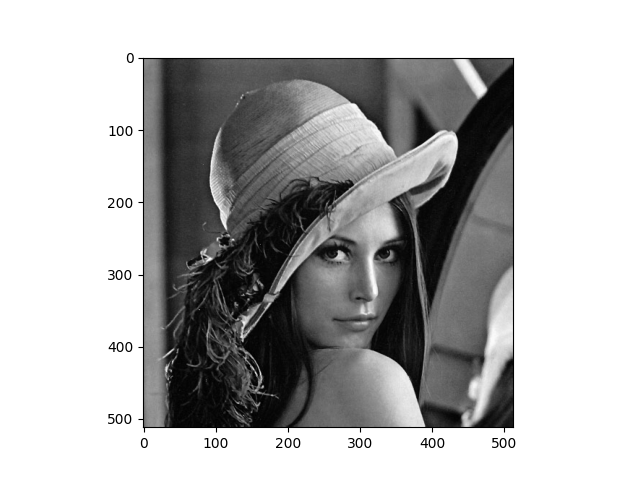

In [28]:
# Hier Lösung einfügen (Insert your solution)

fig, ax = plt.subplots()

def show_image(data: np.typing.NDArray) -> None:
    plt.imshow(data, cmap='gray', vmin=0, vmax=255)

show_image(img)

## 4. Kanten finden _Edge Detection_

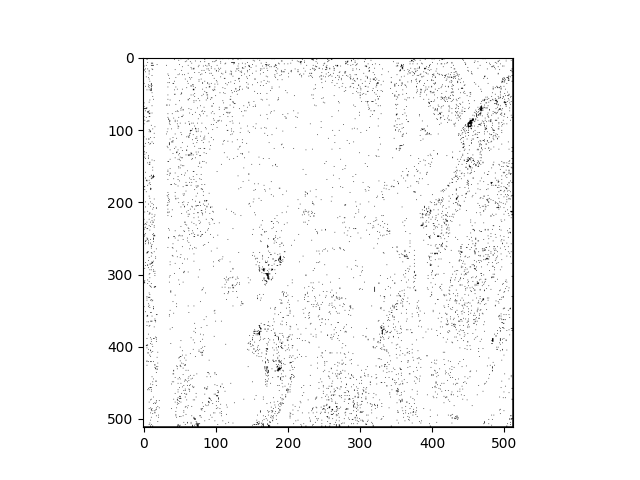

In [29]:
# Hier Lösung einfügen (Insert your solution)

def apply_sobel_x(image:np.typing.NDArray) -> np.typing.NDArray:
    # Sobel-X filter
    filter = np.array([[-1, 0, 1],
                       [-1, 0, 1],
                       [-1, 0, 1]])
    processed_img = np.zeros(image.shape)
    for x in range(0,image.shape[0]-2):
        for y in range(0, image.shape[1]-2):
            new_pixel = 0
            for x_filter in range(0,3):
                for y_filter in range(0,3):
                    new_pixel += image[x+x_filter,y+y_filter] * filter[x_filter,y_filter]
            processed_img[x+1,y+1] = new_pixel
    return processed_img * (255 / np.max(processed_img))

def apply_sobel_y(image:np.typing.NDArray) -> np.typing.NDArray:
    # Sobel-Y filter
    filter = np.array([[-1, -1, -1],
                       [ 0,  0,  0],
                       [ 1,  1,  1]])
    processed_img = np.zeros(image.shape)
    for x in range(0,image.shape[0]-2):
        for y in range(0, image.shape[1]-2):
            new_pixel = 0
            for x_filter in range(0,3):
                for y_filter in range(0,3):
                    new_pixel += image[x+x_filter,y+y_filter] * filter[x_filter,y_filter]
            processed_img[x+1,y+1] = new_pixel
    return processed_img * (255 / np.max(processed_img))

def get_edges(image: np.typing.NDArray) -> np.typing.NDArray:
    image_sobel_x = apply_sobel_x(image)
    image_sobel_y = apply_sobel_y(image)
    image_sobel = np.sqrt(image_sobel_x**2 + image_sobel_y**2)
    normalized = image_sobel * (255 / np.max(image_sobel))
    return normalized.astype("uint8")

edge_img = get_edges(img)

fig, ax = plt.subplots()

def update_image(threshold:int=25) -> np.typing.NDArray:
    binarized = np.zeros(edge_img.shape)
    binarized[edge_img>threshold]=255
    return binarized

controls = iplt.imshow(update_image, cmap='gray', vmin=0, vmax=255, threshold=(0,255))